
Performance Comparison Table

   Input Size  Binary Time (s)  Binary Comparisons  Interpolation Time (s)  \
0        1000         0.000005                   9                0.000006   
1        5000         0.000004                  12                0.000002   
2       10000         0.000003                  13                0.000001   
3       50000         0.000006                  15                0.000003   
4      100000         0.000007                  16                0.000003   

   Interpolation Comparisons  
0                          1  
1                          1  
2                          1  
3                          1  
4                          1  

Binary Search
Time Complexity: O(log n)
Space Complexity: O(1)

Interpolation Search
Best Case: O(1)
Average Case: O(log log n)
Worst Case: O(n)
Space Complexity: O(1)


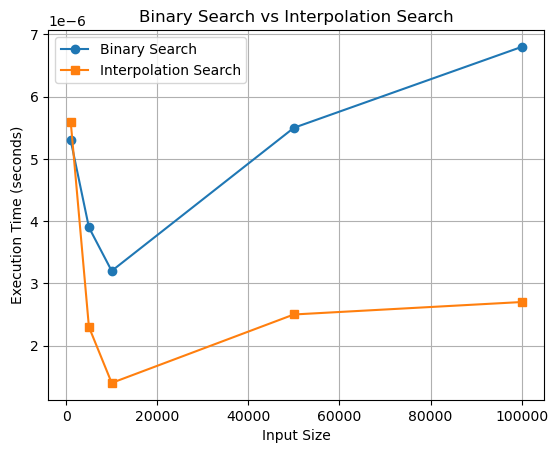

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Binary Search
def binary_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high:
        comparisons += 1
        mid = (low + high) // 2

        if arr[mid] == key:
            return mid, comparisons
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons


# Interpolation Search
def interpolation_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high and key >= arr[low] and key <= arr[high]:

        comparisons += 1

        if arr[high] == arr[low]:
            if arr[low] == key:
                return low, comparisons
            return -1, comparisons

        pos = low + int(
            ((high - low) / (arr[high] - arr[low]))
            * (key - arr[low])
        )

        if arr[pos] == key:
            return pos, comparisons

        elif arr[pos] < key:
            low = pos + 1

        else:
            high = pos - 1

    return -1, comparisons


# Different input sizes
sizes = [1000, 5000, 10000, 50000, 100000]

binary_times = []
interp_times = []
results = []

for n in sizes:

    arr = [i for i in range(n)]
    key = arr[n // 2]

    # Binary Search
    start = time.perf_counter()
    pos1, comp1 = binary_search(arr, key)
    end = time.perf_counter()
    binary_time = end - start

    # Interpolation Search
    start = time.perf_counter()
    pos2, comp2 = interpolation_search(arr, key)
    end = time.perf_counter()
    interp_time = end - start

    binary_times.append(binary_time)
    interp_times.append(interp_time)

    results.append([
        n,
        binary_time,
        comp1,
        interp_time,
        comp2
    ])

# Display Table
df = pd.DataFrame(
    results,
    columns=[
        "Input Size",
        "Binary Time (s)",
        "Binary Comparisons",
        "Interpolation Time (s)",
        "Interpolation Comparisons"
    ]
)

print("\nPerformance Comparison Table\n")
print(df)

# Complexity Information
print("\nBinary Search")
print("Time Complexity: O(log n)")
print("Space Complexity: O(1)")

print("\nInterpolation Search")
print("Best Case: O(1)")
print("Average Case: O(log log n)")
print("Worst Case: O(n)")
print("Space Complexity: O(1)")

# Plot Graph
plt.plot(sizes, binary_times, marker='o', label='Binary Search')
plt.plot(sizes, interp_times, marker='s', label='Interpolation Search')

plt.title("Binary Search vs Interpolation Search")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.legend()
plt.grid(True)

plt.show()